# Laboratorio - Péndulo Simple utilizando Phyphox

Análisis de datos experimentales obtenidos mediante el sensor giroscópico de un dispositivo móvil.

Autores:
- Tu nombre
- Integrante 2
- Integrante 3

In [1]:
import pandas as pd   # Leer archivo Excel
import matplotlib.pyplot as plt  # Graficas
import numpy as np  # Calculos

Verificar lectura archivo


In [2]:
archivo = "Pndulo 2026-07-27 12-50-50.xls"

excel = pd.ExcelFile(archivo)

print(excel.sheet_names)

['Raw Data', 'Autocorrelation', 'Resonance', 'Metadata Device', 'Metadata Time']


RAW DATA

In [4]:
datos = pd.read_excel(archivo,
                      sheet_name="Raw Data")

pRIMEROS 5 DATO S

In [5]:
datos.head()

,Time (s),Rotation x (rad/s),Rotation y (rad/s),Rotation z (rad/s)
0,0.044678,0.107818,0.021838,0.000916
1,0.065331,0.044899,-0.012675,0.072540
2,0.085984,0.009621,0.011606,0.098502
3,0.106637,0.005192,0.050549,0.081398
4,0.127290,0.012828,0.007789,0.016035


TAMAÑO DATOS

In [6]:
datos.shape

(484, 4)

Verificar si existen datos faltantes

In [7]:
datos.isnull().sum()

,0
Time (s),0
Rotation x (rad/s),0
Rotation y (rad/s),0
Rotation z (rad/s),0


In [8]:
datos.describe()

,Time (s),Rotation x (rad/s),Rotation y (rad/s),Rotation z (rad/s)
count,484.000000,484.000000,484.000000,484.000000
mean,5.032358,-0.018200,0.009543,-0.100039
std,2.888569,0.073535,0.409490,2.022052
min,0.044678,-0.206167,-0.973718,-6.205928
25%,2.538529,-0.068722,-0.374460,-1.781396
50%,5.032366,-0.026573,0.011759,-0.182954
75%,7.526190,0.030391,0.385379,1.724929
max,10.020004,0.242055,1.455843,4.469239


Variables

In [9]:
print(datos.columns)

Index(['Time (s)', 'Rotation x (rad/s)', 'Rotation y (rad/s)',
       'Rotation z (rad/s)'],
      dtype='object')


In [11]:
tiempo = datos['Time (s)']
rot_x = datos['Rotation x (rad/s)']
rot_y = datos['Rotation y (rad/s)']
rot_z = datos['Rotation z (rad/s)']

grafica uno

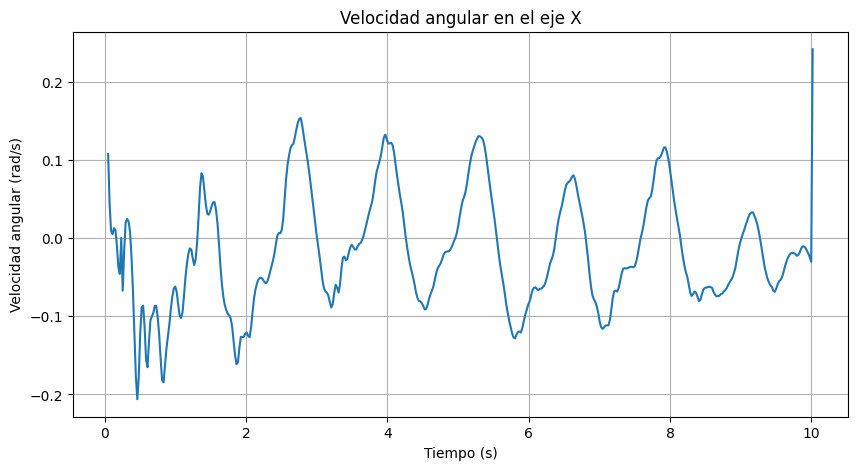

In [12]:
plt.figure(figsize=(10,5))

plt.plot(tiempo, rot_x)

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad angular (rad/s)")
plt.title("Velocidad angular en el eje X")

plt.grid()

plt.show()

Segunda grafica

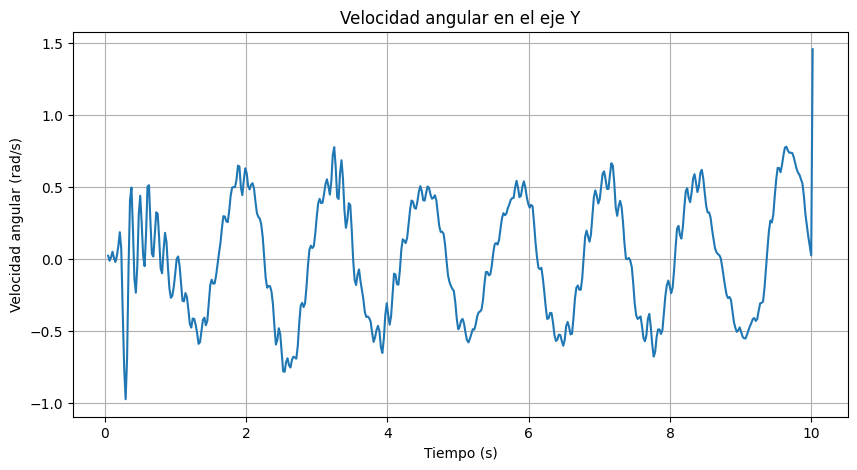

In [13]:
plt.figure(figsize=(10,5))

plt.plot(tiempo, rot_y)

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad angular (rad/s)")
plt.title("Velocidad angular en el eje Y")

plt.grid()

plt.show()

TEercera grafica

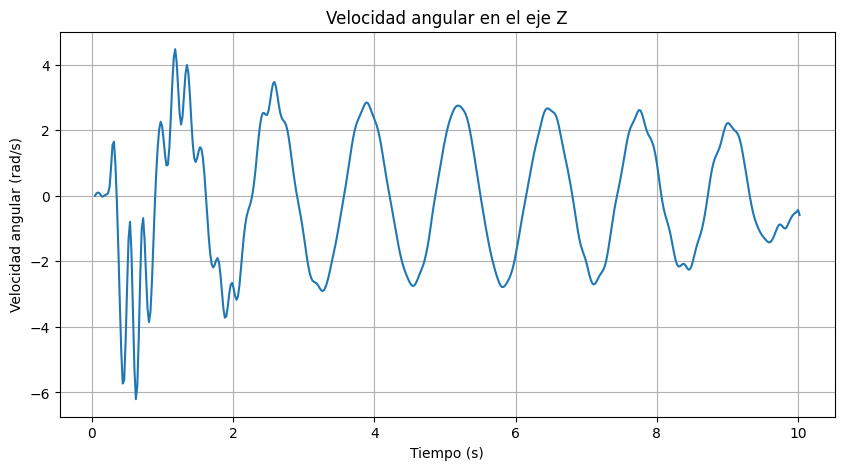

In [14]:
plt.figure(figsize=(10,5))

plt.plot(tiempo, rot_z)

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad angular (rad/s)")
plt.title("Velocidad angular en el eje Z")

plt.grid()

plt.show()

Cuarta Grafica

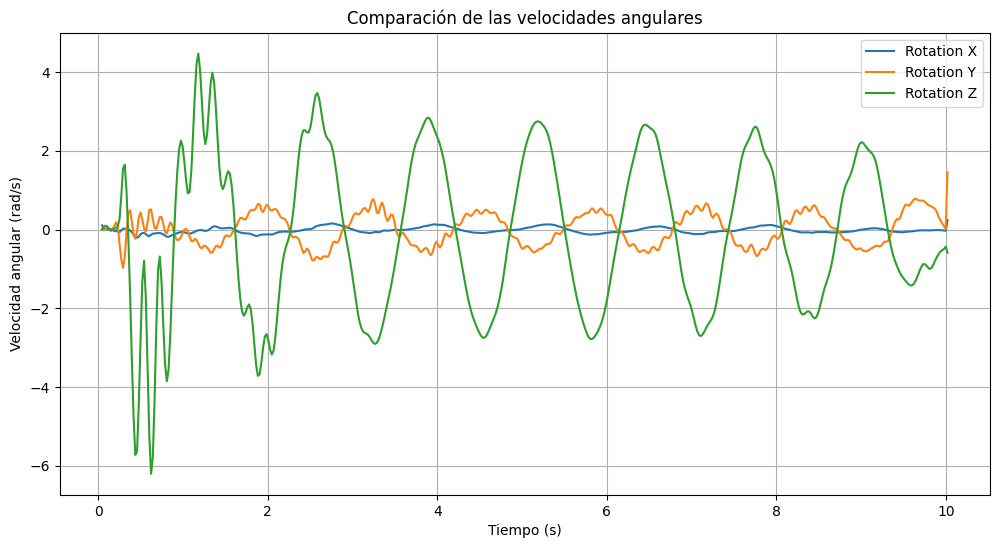

In [15]:
plt.figure(figsize=(12,6))

plt.plot(tiempo, rot_x, label="Rotation X")
plt.plot(tiempo, rot_y, label="Rotation Y")
plt.plot(tiempo, rot_z, label="Rotation Z")

plt.xlabel("Tiempo (s)")
plt.ylabel("Velocidad angular (rad/s)")
plt.title("Comparación de las velocidades angulares")

plt.legend()
plt.grid()

plt.show()

Grafica auto crrelacion

In [17]:
auto = pd.read_excel(archivo, sheet_name="Autocorrelation")

print(auto.columns)

auto.head()

Index(['Time shift (s)', 'Autocorrelation of sum'], dtype='object')


,Time shift (s),Autocorrelation of sum
0,0.000000,3.030938
1,0.020653,2.965395
2,0.041306,2.791906
3,0.061959,2.567107
4,0.082612,2.357491


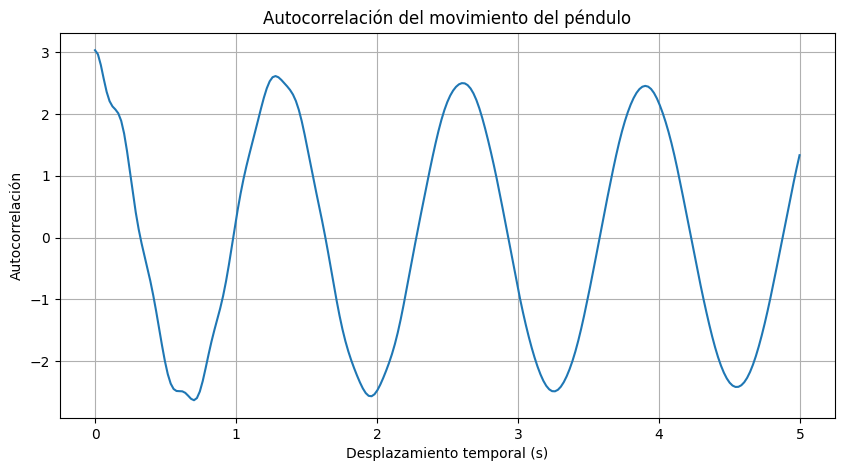

In [30]:
# Leer la hoja Autocorrelation
auto = pd.read_excel(archivo, sheet_name="Autocorrelation")

# Crear las variables
time_shift = auto["Time shift (s)"]
autocorrelation = auto["Autocorrelation of sum"]

# Graficar
plt.figure(figsize=(10,5))

plt.plot(time_shift, autocorrelation)

plt.xlabel("Desplazamiento temporal (s)")
plt.ylabel("Autocorrelación")
plt.title("Autocorrelación del movimiento del péndulo")

plt.grid(True)

plt.show()

In [29]:
# Librería para encontrar picos
from scipy.signal import find_peaks

# Leer la hoja
auto = pd.read_excel(archivo, sheet_name="Autocorrelation")

# Variables
time_shift = auto["Time shift (s)"]
autocorrelation = auto["Autocorrelation of sum"]

# Encontrar los picos de la señal
picos, _ = find_peaks(autocorrelation)

# Mostrar los tiempos donde aparecen los picos
print("Tiempos donde se encontraron los máximos:")

print(time_shift.iloc[picos])

Tiempos donde se encontraron los máximos:
62     1.280489
126    2.602280
189    3.903413
Name: Time shift (s), dtype: float64


In [24]:
# Calcular la diferencia entre los máximos

periodos = np.diff(time_shift.iloc[picos])

print("Periodos encontrados:")

print(periodos)

periodo_promedio = np.mean(periodos)

print("Periodo experimental promedio:")

print(periodo_promedio)

frecuencia_experimental = 1/periodo_promedio

print("Frecuencia experimental:")

print(frecuencia_experimental)

Periodos encontrados:
[1.32179047 1.30113328]
Periodo experimental promedio:
1.3114618750000002
Frecuencia experimental:
0.762507869319495


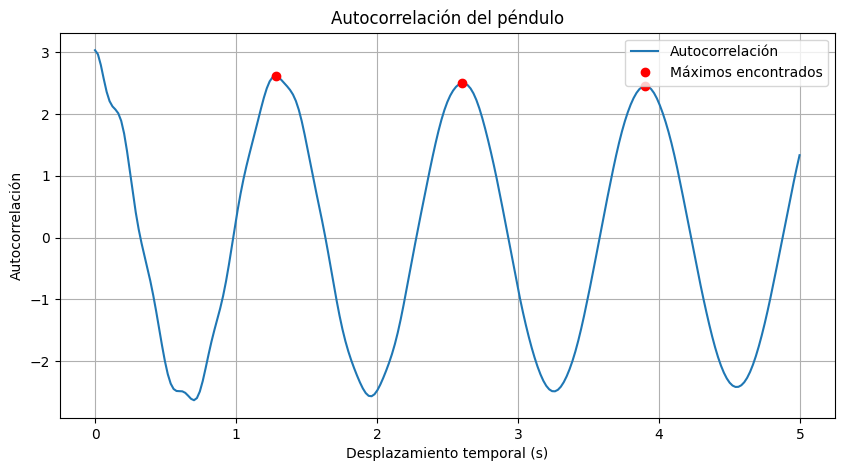

In [25]:
plt.figure(figsize=(10,5))

plt.plot(time_shift,
         autocorrelation,
         label="Autocorrelación")

plt.plot(time_shift.iloc[picos],
         autocorrelation.iloc[picos],
         "ro",
         label="Máximos encontrados")

plt.xlabel("Desplazamiento temporal (s)")
plt.ylabel("Autocorrelación")

plt.title("Autocorrelación del péndulo")

plt.legend()
plt.grid(True)

plt.show()

Grafica resonancia

In [18]:
res = pd.read_excel(archivo, sheet_name="Resonance")
print(res.columns)
res.head()

Index(['Frequency (Hz)', 'Rel. amplitude (a.u.)'], dtype='object')


,Frequency (Hz),Rel. amplitude (a.u.)
0,0.756549,0.994779
1,0.756549,0.994779
2,0.756549,0.994779
3,0.756549,0.995915
4,0.756549,0.996936


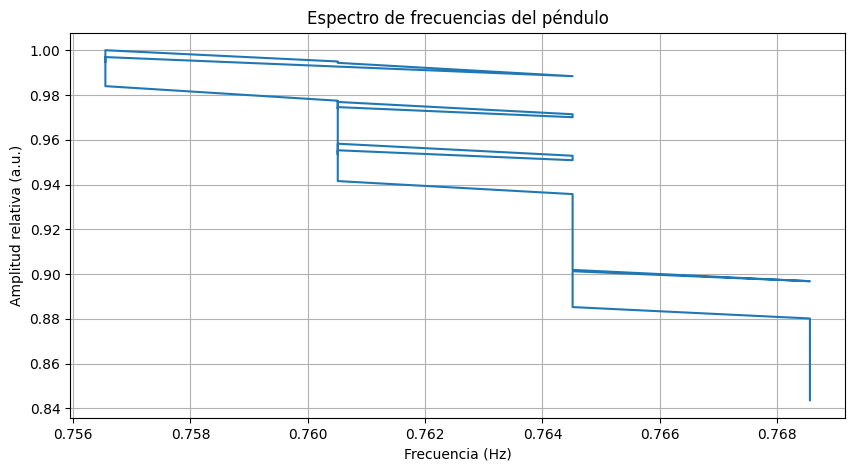

In [20]:
#grafica
# Leer la hoja Resonance
res = pd.read_excel(archivo, sheet_name="Resonance")

# Crear las variables
frecuencia = res["Frequency (Hz)"]
amplitud = res["Rel. amplitude (a.u.)"]

# Graficar
plt.figure(figsize=(10,5))

plt.plot(frecuencia, amplitud)

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud relativa (a.u.)")
plt.title("Espectro de frecuencias del péndulo")

plt.grid(True)

plt.show()

In [27]:
indice_maximo = amplitud.idxmax()

frecuencia_principal = frecuencia[indice_maximo]

amplitud_maxima = amplitud[indice_maximo]

print("Frecuencia predominante:")

print(frecuencia_principal)

print("\nAmplitud relativa:")

print(amplitud_maxima)

Frecuencia predominante:
0.7565494724249537

Amplitud relativa:
1.0


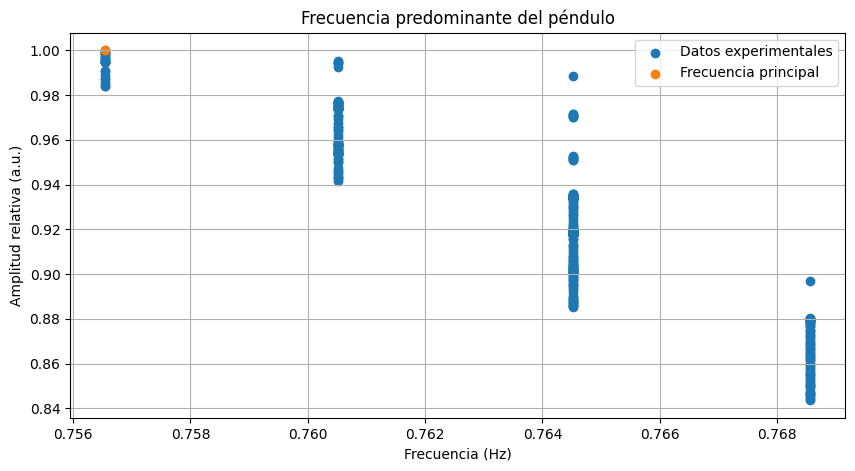

In [31]:
plt.figure(figsize=(10,5))

plt.scatter(frecuencia,
            amplitud,
            label="Datos experimentales")

plt.scatter(frecuencia_principal,
            amplitud_maxima,
            label="Frecuencia principal")

plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud relativa (a.u.)")

plt.title("Frecuencia predominante del péndulo")

plt.grid(True)
plt.legend()

plt.show()

In [32]:
g = 9.81

longitud = g*(periodo_promedio/(2*np.pi))**2

print(f"Longitud estimada = {longitud:.4f} metros")

Longitud estimada = 0.4274 metros


In [33]:
# Calculo del error porcentual

error = abs(frecuencia_experimental - frecuencia_principal)

error_porcentual = (error/frecuencia_principal)*100

print(f"Error porcentual = {error_porcentual:.2f}%")

Error porcentual = 0.79%
